# Sports Analytics Club Advanced Demo

1. Visualization examples
2. Baseline logistic regression
3. Baseline XGBoost
4. Model-to-simulation workflow for 2026 matchups
5. Monte Carlo visuals:
   - all first-round matchup predictions
   - top 10 teams and probability of advancing through each round

In [1]:
# Run this once per new environment/kernel.
# If your notebook starts in /notebooks, this installs from repo-root requirements.
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import io
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score


# You may need to tweak the paths below your directory structure differs!
project_root = Path.cwd().parent
share_path = project_root / "data" / "processed" / "club_share"
matchups_path = share_path / "m_historical_matchups_2005_2025.csv"
team_agg_path = share_path / "m_team_aggregates_2005_2026.csv"
matchups_2026_all_path = share_path / "m_modeling_matchups_2026_all_possible.csv"
first_round_candidates_path = share_path / "m_first_round_matchups_2026_68team_candidates.csv"

required_paths = [
    matchups_path,
    team_agg_path,
    matchups_2026_all_path,
    first_round_candidates_path,
]
missing_paths = [str(p) for p in required_paths if not p.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Change directory set-up to local configuration. Missing files:\n" + "\n".join(missing_paths)
    )

matchups = pd.read_csv(matchups_path)
team_agg = pd.read_csv(team_agg_path)
matchups_2026_all = pd.read_csv(matchups_2026_all_path)
first_round_candidates_2026 = pd.read_csv(first_round_candidates_path)

print(f"Matchups rows: {len(matchups):,}")
print(f"Team aggregates rows: {len(team_agg):,}")
print(f"2026 all-possible matchup rows: {len(matchups_2026_all):,}")
print(f"2026 first-round 68-team candidate rows: {len(first_round_candidates_2026):,}")
display(matchups.head(3))
display(team_agg.head(3))
display(matchups_2026_all.head(3))
display(first_round_candidates_2026.head(3))

PLAY_IN_SEEDS = {11, 16}


def get_or_load_team_agg() -> pd.DataFrame:
    """Return team_agg from memory when available; otherwise reload from CSV."""
    global team_agg

    if "team_agg" in globals() and isinstance(team_agg, pd.DataFrame) and not team_agg.empty:
        return team_agg

    if "team_agg_path" in globals() and Path(team_agg_path).exists():
        team_agg = pd.read_csv(team_agg_path)
        return team_agg

    fallback_dir = Path.cwd().parent / "data" / "processed" / "club_share"
    fallback_candidates = sorted(fallback_dir.glob("m_team_aggregates_*_2026.csv"))
    if fallback_candidates:
        team_agg = pd.read_csv(fallback_candidates[-1])
        return team_agg

    raise RuntimeError("team_agg is unavailable. Run Cell 3 first or ensure team aggregate CSV exists.")


def get_first_round_candidates(season=2026) -> pd.DataFrame:
    """Return precomputed first-round matchup candidates (includes play-in alternates)."""
    global first_round_candidates_2026

    if (
        "first_round_candidates_2026" not in globals()
        or not isinstance(first_round_candidates_2026, pd.DataFrame)
        or first_round_candidates_2026.empty
    ):
        if "first_round_candidates_path" in globals() and Path(first_round_candidates_path).exists():
            first_round_candidates_2026 = pd.read_csv(first_round_candidates_path)
        else:
            raise RuntimeError("first_round_candidates_2026 is unavailable. Run Cell 3 first.")

    work_df = first_round_candidates_2026.copy()
    if "Season" in work_df.columns:
        season_num = pd.to_numeric(work_df["Season"], errors="coerce")
        work_df = work_df.loc[season_num == int(season)].copy()

    if work_df.empty:
        raise RuntimeError(f"No first-round candidate rows found for season {season}.")

    return work_df


def build_tourney_eligible_pool(prefer_season=2026) -> pd.DataFrame:
    """Build a unique team pool for bracket-eligible teams from first-round candidate rows."""
    first_round_df = get_first_round_candidates(prefer_season).copy()

    required_cols = [
        "Region",
        "FavoriteTeamID",
        "FavoriteSeed",
        "UnderdogTeamID",
        "UnderdogSeed",
    ]
    missing_cols = [c for c in required_cols if c not in first_round_df.columns]
    if missing_cols:
        raise RuntimeError("Missing expected first-round columns: " + ", ".join(missing_cols))

    favorite_pool = first_round_df[["Region", "FavoriteTeamID", "FavoriteSeed"]].rename(
        columns={"FavoriteTeamID": "TeamID", "FavoriteSeed": "SeedNum"}
    )
    underdog_pool = first_round_df[["Region", "UnderdogTeamID", "UnderdogSeed"]].rename(
        columns={"UnderdogTeamID": "TeamID", "UnderdogSeed": "SeedNum"}
    )

    eligible_pool = pd.concat([favorite_pool, underdog_pool], ignore_index=True)
    eligible_pool["TeamID"] = pd.to_numeric(eligible_pool["TeamID"], errors="coerce")
    eligible_pool["SeedNum"] = pd.to_numeric(eligible_pool["SeedNum"], errors="coerce")
    eligible_pool["Region"] = eligible_pool["Region"].astype(str).str.upper().str.strip()

    eligible_pool = eligible_pool.dropna(subset=["TeamID", "SeedNum", "Region"]).copy()
    eligible_pool["TeamID"] = eligible_pool["TeamID"].astype(int)
    eligible_pool["SeedNum"] = eligible_pool["SeedNum"].astype(int)

    eligible_pool = eligible_pool.drop_duplicates(subset=["TeamID", "Region", "SeedNum"]).reset_index(drop=True)
    return eligible_pool


def build_visual_base_df(required_cols=None, min_games=10, prefer_season=2026):
    """Create a consistent visual base dataframe independent of other visualization cells."""
    required_cols = required_cols or []

    visual_work_df = get_or_load_team_agg().copy()
    visual_work_df["Season_num"] = pd.to_numeric(visual_work_df.get("Season"), errors="coerce")
    visual_work_df["games_played_num"] = pd.to_numeric(
        visual_work_df.get("games_played", pd.Series(index=visual_work_df.index, dtype=float)),
        errors="coerce",
    )

    usable_mask = visual_work_df["games_played_num"].ge(min_games)

    for col in required_cols:
        if col not in visual_work_df.columns:
            raise RuntimeError(f"Required column '{col}' not found in team_agg.")
        usable_mask &= visual_work_df[col].notna()

    season_counts = visual_work_df.loc[usable_mask].groupby("Season_num").size()
    if season_counts.empty:
        raise RuntimeError("No season has usable rows for requested visualization inputs.")

    selected_season = int(prefer_season) if prefer_season in season_counts.index else int(season_counts.index.max())
    visual_base_df = visual_work_df.loc[
        (visual_work_df["Season_num"] == selected_season) & usable_mask
    ].copy()

    return visual_work_df, visual_base_df, selected_season

Matchups rows: 1,321
Team aggregates rows: 7,798
2026 all-possible matchup rows: 2,278
2026 first-round 68-team candidate rows: 36


,Season,DayNum,Team1ID,Team2ID,Team1_TeamName,Team2_TeamName,Team1_Seed,Team2_Seed,Diff_SeedNum,Target_Team1Win,...,Diff_pyth_win_pct,Diff_sos_adj_net_rating,Diff_three_factors_composite,Diff_weighted_massey_momentum,Team1_Color,Team1_AlternateColor,Team1_Logo,Team2_Color,Team2_AlternateColor,Team2_Logo
0,2005,134,1105,1324,Alabama A&M,Oakland,Z16a,Z16b,0.5,0,...,0.059791,-8.053033,0.211558,-2.046903,790000,ffffff,https://a.espncdn.com/i/teamlogos/ncaa/500/201...,04091c,bc955c,https://a.espncdn.com/i/teamlogos/ncaa/500/247...
1,2005,136,1112,1429,Arizona,Utah St,X03,X14,11.0,1,...,-0.117182,-4.612147,-0.408777,0.173382,0c234b,003366,https://a.espncdn.com/i/teamlogos/ncaa/500/12.png,00263a,949ca1,https://a.espncdn.com/i/teamlogos/ncaa/500/328...
2,2005,136,1130,1335,Boston College,Penn,X04,X13,9.0,1,...,0.056762,18.831034,0.071363,0.026081,8c2232,dbcca6,https://a.espncdn.com/i/teamlogos/ncaa/500/103...,082A74,a6163d,https://a.espncdn.com/i/teamlogos/ncaa/500/219...


,Season,TeamID,TeamName,Seed,Adj_Massey,Adj_Seed,Colley_Momentum,Final_Colley,Final_Massey,Massey_Momentum,...,playmaking_defense_composite,pyth_win_pct,sos_adj_net_rating,three_factors_composite,weighted_massey_momentum,TeamColor,TeamAlternateColor,TeamLogo,SeedRegion,SeedPlayInSuffix
0,2005,1102,Air Force,NaN,NaN,10.0,0.005257,0.653719,9.771301,0.541365,...,1.490112,0.812950,0.661508,0.988058,0.191098,003594,ffffff,https://a.espncdn.com/i/teamlogos/ncaa/500/200...,NaN,NaN
1,2005,1103,Akron,NaN,NaN,11.0,0.033315,0.663638,8.113312,-0.436603,...,0.567715,0.684013,0.119696,0.353393,-0.170160,00285e,84754e,https://a.espncdn.com/i/teamlogos/ncaa/500/200...,NaN,NaN
2,2005,1104,Alabama,X05,1.822595,6.0,-0.013250,0.882528,16.873810,0.932868,...,0.454006,0.831679,8.177312,0.671591,0.192873,9e1632,ffffff,https://a.espncdn.com/i/teamlogos/ncaa/500/333...,NaN,NaN


,Season,Team1ID,Team2ID,Team1_TeamName,Team2_TeamName,Team1_Seed,Team2_Seed,Team1_SeedRegion,Team2_SeedRegion,Team1_Field68Role,...,Diff_pyth_win_pct,Diff_sos_adj_net_rating,Diff_three_factors_composite,Diff_weighted_massey_momentum,Team1_Color,Team1_AlternateColor,Team1_Logo,Team2_Color,Team2_AlternateColor,Team2_Logo
0,2026,1181,1112,Duke,Arizona,W01,Z01,W,Z,primary,...,0.024723,12.779964,0.247467,0.233461,00539b,ffffff,https://a.espncdn.com/i/teamlogos/ncaa/500/150...,0c234b,003366,https://a.espncdn.com/i/teamlogos/ncaa/500/12.png
1,2026,1112,1196,Arizona,Florida,Z01,X01,Z,X,primary,...,0.034980,-1.999963,0.123857,-0.330847,0c234b,003366,https://a.espncdn.com/i/teamlogos/ncaa/500/12.png,0021a5,fa4616,https://a.espncdn.com/i/teamlogos/ncaa/500/57.png
2,2026,1276,1112,Michigan,Arizona,Y01,Z01,Y,Z,primary,...,0.005670,2.471907,-0.198232,0.006314,00274c,ffcb05,https://a.espncdn.com/i/teamlogos/ncaa/500/130...,0c234b,003366,https://a.espncdn.com/i/teamlogos/ncaa/500/12.png


,DataPrefix,Season,Region,FavoriteSeed,UnderdogSeed,Diff_SeedNum,FavoriteSeedCode,UnderdogSeedCode,FavoriteTeamID,UnderdogTeamID,...,Model_Team1_SeedRegion,Model_Team1_TeamName,Model_Team2ID,Model_Team2_AlternateColor,Model_Team2_Color,Model_Team2_Field68Role,Model_Team2_Logo,Model_Team2_Seed,Model_Team2_SeedRegion,Model_Team2_TeamName
0,m,2026,W,1,16,15,W01,W16,1181,1373,...,W,Duke,1373,eea60f,037961,primary,https://a.espncdn.com/i/teamlogos/ncaa/500/256...,W16,W,Siena
1,m,2026,W,2,15,13,W02,W15,1163,1202,...,W,Connecticut,1202,ffffff,582c83,primary,https://a.espncdn.com/i/teamlogos/ncaa/500/231...,W15,W,Furman
2,m,2026,W,3,14,11,W03,W14,1277,1295,...,W,Michigan St,1295,ffffff,01402A,primary,https://a.espncdn.com/i/teamlogos/ncaa/500/244...,W14,W,N Dakota St


In [3]:
def format_hex_color(c, default="#4682b4"):
    """Normalize team color strings to '#RRGGBB'-style values with a fallback."""
    if pd.isna(c) or not str(c).strip():
        return default
    c_str = str(c).strip()
    if not c_str.startswith("#"):
        if len(c_str) in [3, 6, 8]:
            return "#" + c_str
        return default
    return c_str

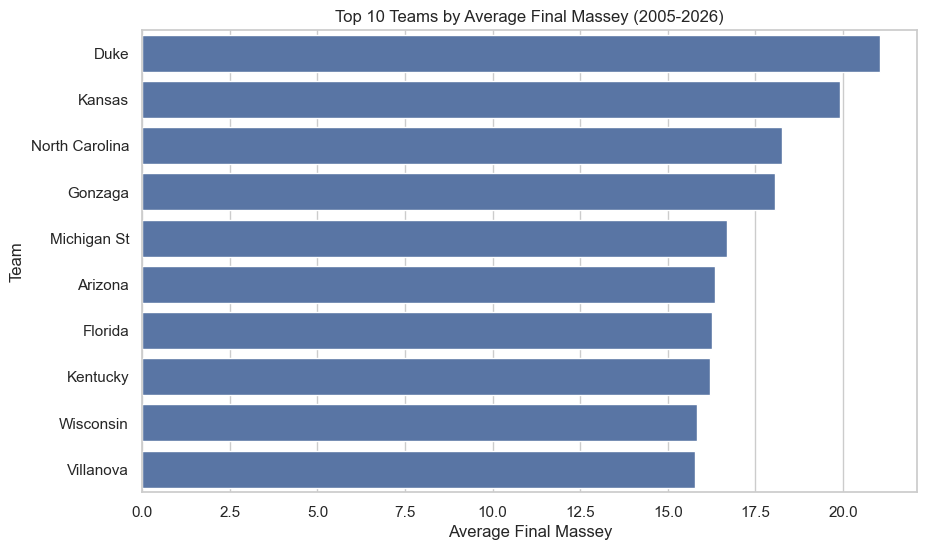

In [4]:
sns.set_theme(style="whitegrid")

team_agg_chart_df = get_or_load_team_agg().copy()

if "Final_Massey" in team_agg_chart_df.columns:
    chart_df = (
        team_agg_chart_df[team_agg_chart_df["Season"].between(2005, 2026)]
        .groupby("TeamName", as_index=False)["Final_Massey"]
        .mean()
        .sort_values("Final_Massey", ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(data=chart_df, x="Final_Massey", y="TeamName")
    plt.title("Top 10 Teams by Average Final Massey (2005-2026)")
    plt.xlabel("Average Final Massey")
    plt.ylabel("Team")
    plt.show()
else:
    print("`Final_Massey` not found in team_agg; skipping visualization cell.")

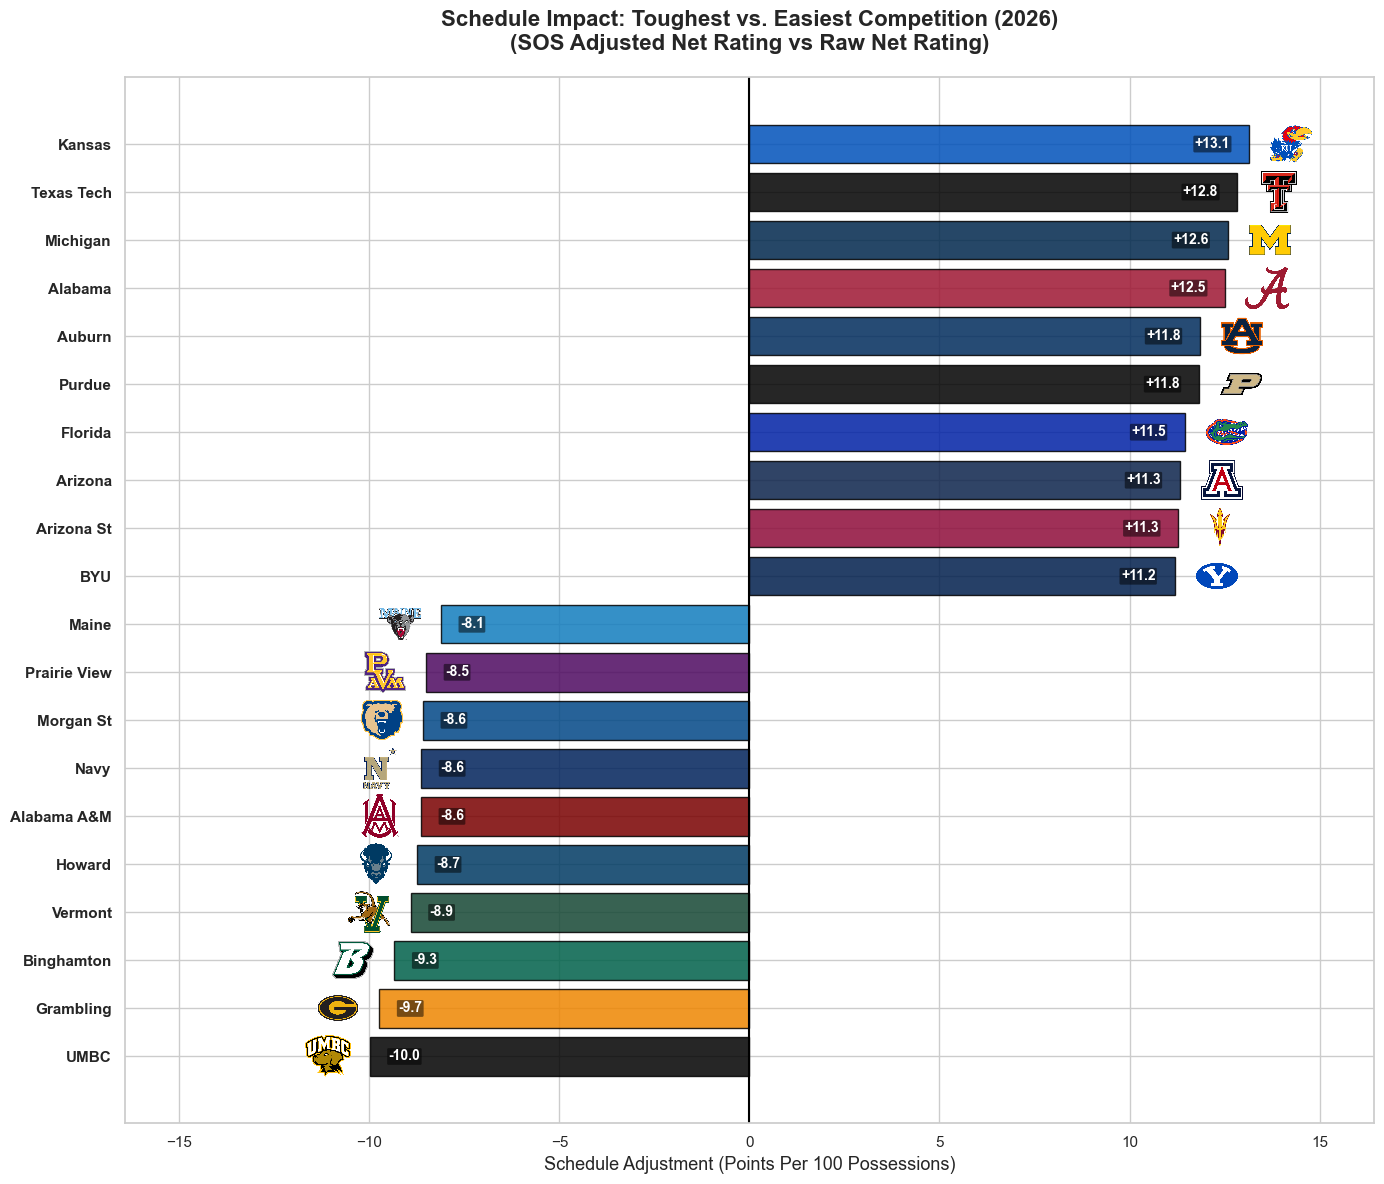

In [5]:
# ==========================================
# VISUALIZATION: Schedule Impact (SOS Adjustment)
# ==========================================

# 1. Data Preparation
_, schedule_base_df, schedule_demo_season = build_visual_base_df(
    required_cols=["adj_net_rating", "sos_adj_net_rating"],
    min_games=10,
    prefer_season=2026,
)

# Calculate the Schedule Adjustment
# Positive = Played tougher teams (SOS boosts their rating)
# Negative = Played weaker teams (SOS penalizes their rating)
schedule_base_df["sos_diff"] = (
    schedule_base_df["sos_adj_net_rating"] - schedule_base_df["adj_net_rating"]
)

# Grab the Top 10 (Toughest Schedules) and Bottom 10 (Easiest Schedules)
schedule_top_10 = schedule_base_df.nlargest(10, "sos_diff")
schedule_bottom_10 = schedule_base_df.nsmallest(10, "sos_diff")

# Combine and sort for the horizontal bar chart
schedule_plot_df = pd.concat([schedule_top_10, schedule_bottom_10]).sort_values("sos_diff")

# 2. Color Preparation
schedule_plot_df["primary_color"] = schedule_plot_df.get(
    "TeamColor", pd.Series(dtype=str)
).apply(lambda x: format_hex_color(x, "#4682b4"))

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(14, 12))
sns.set_theme(style="whitegrid")

y_positions = np.arange(len(schedule_plot_df))
bars = ax.barh(
    y_positions,
    schedule_plot_df["sos_diff"],
    color=schedule_plot_df["primary_color"],
    alpha=0.85,
    edgecolor="black",
)

ax.set_yticks(y_positions)
ax.set_yticklabels(schedule_plot_df["TeamName"], fontweight="bold")

plt.title(
    f"Schedule Impact: Toughest vs. Easiest Competition ({schedule_demo_season})\n"
    "(SOS Adjusted Net Rating vs Raw Net Rating)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Schedule Adjustment (Points Per 100 Possessions)", fontsize=13)

ax.axvline(x=0, color="black", linewidth=1.5, linestyle="-")

max_abs_val = schedule_plot_df["sos_diff"].abs().max()
ax.set_xlim(-max_abs_val * 1.25, max_abs_val * 1.25)

# 4. Logo Placement Logic
for idx, (bar, (_, row)) in enumerate(zip(bars, schedule_plot_df.iterrows())):
    val = row["sos_diff"]
    logo_url = row.get("TeamLogo", None)

    if pd.notna(logo_url) and str(logo_url).startswith("http"):
        try:
            req = urllib.request.Request(logo_url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=2) as response:
                img = Image.open(io.BytesIO(response.read())).convert("RGBA")

            imagebox = OffsetImage(img, zoom=0.065)
            x_offset = val + (0.5 if val > 0 else -0.5)
            ab = AnnotationBbox(
                imagebox,
                (x_offset, idx),
                frameon=False,
                pad=0,
                box_alignment=(0 if val > 0 else 1, 0.5),
            )
            ax.add_artist(ab)
        except Exception:
            pass

    text_x = val - (0.5 if val > 0 else -0.5)
    ha = "right" if val > 0 else "left"
    ax.annotate(
        f"{val:+.1f}",
        (text_x, idx),
        va="center",
        ha=ha,
        color="white",
        fontweight="bold",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.1", fc="black", ec="none", alpha=0.5),
    )

plt.tight_layout()
plt.show()

In [6]:
# ==========================================
# ANALYSIS: Specific Team Schedule Impacts
# ==========================================
import pandas as pd
from IPython.display import display, Markdown

# Build a local schedule analysis frame so this cell can run independently.
_, schedule_analysis_base_df, schedule_analysis_season = build_visual_base_df(
    required_cols=["adj_net_rating", "sos_adj_net_rating"],
    min_games=10,
    prefer_season=2026,
)
schedule_analysis_base_df["sos_diff"] = (
    schedule_analysis_base_df["sos_adj_net_rating"] - schedule_analysis_base_df["adj_net_rating"]
)

# 1. Overall Season Metrics
total_teams = len(schedule_analysis_base_df)
mean_impact = schedule_analysis_base_df["sos_diff"].mean()
median_impact = schedule_analysis_base_df["sos_diff"].median()

display(Markdown(f"### {schedule_analysis_season} Schedule Impact Overview"))
display(Markdown(f"- **Total Teams:** {total_teams}"))
display(Markdown(f"- **Mean Impact:** `{mean_impact:+.2f}`"))
display(Markdown(f"- **Median Impact:** `{median_impact:+.2f}`"))

# 2. Specific Team Lookups
teams_to_check = ["Miami OH", "Charlotte"]
results = []

for team in teams_to_check:
    team_row = schedule_analysis_base_df[schedule_analysis_base_df["TeamName"] == team]

    if not team_row.empty:
        diff_val = team_row["sos_diff"].values[0]
        net_val = team_row["sos_adj_net_rating"].values[0]

        rank = (schedule_analysis_base_df["sos_diff"] > diff_val).sum() + 1

        results.append(
            {
                "Team": team,
                "SOS-Adj Net Rating": round(net_val, 2),
                "Schedule Impact": round(diff_val, 2),
                "Impact Rank": f"#{rank} of {total_teams}",
            }
        )
    else:
        results.append(
            {
                "Team": team,
                "SOS-Adj Net Rating": pd.NA,
                "Schedule Impact": pd.NA,
                "Impact Rank": "Not Found",
            }
        )

# 3. Display as a styled DataFrame
results_df = pd.DataFrame(results)

def color_impact(val):
    if pd.isna(val) or isinstance(val, str):
        return ""
    color = "#27ae60" if val > 0 else "#e74c3c"
    return f"color: {color}; font-weight: bold"

display(Markdown("### Target Teams Analysis"))
display(
    results_df.style
    .format(
        {
            "SOS-Adj Net Rating": "{:+.2f}",
            "Schedule Impact": "{:+.2f}",
        },
        na_rep="-",
    )
    .map(color_impact, subset=["Schedule Impact"])
    .set_properties(**{"text-align": "center", "font-size": "14px"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-size", "14px"),
                    ("color", "black"),
                    ("background-color", "#f2f2f2"),
                ],
            }
        ]
    )
    .hide(axis="index")
)

### 2026 Schedule Impact Overview

- **Total Teams:** 365

- **Mean Impact:** `+0.38`

- **Median Impact:** `-0.46`

### Target Teams Analysis

Team,SOS-Adj Net Rating,Schedule Impact,Impact Rank
Miami OH,+2.60,-4.30,#279 of 365
Charlotte,-6.23,+1.23,#135 of 365


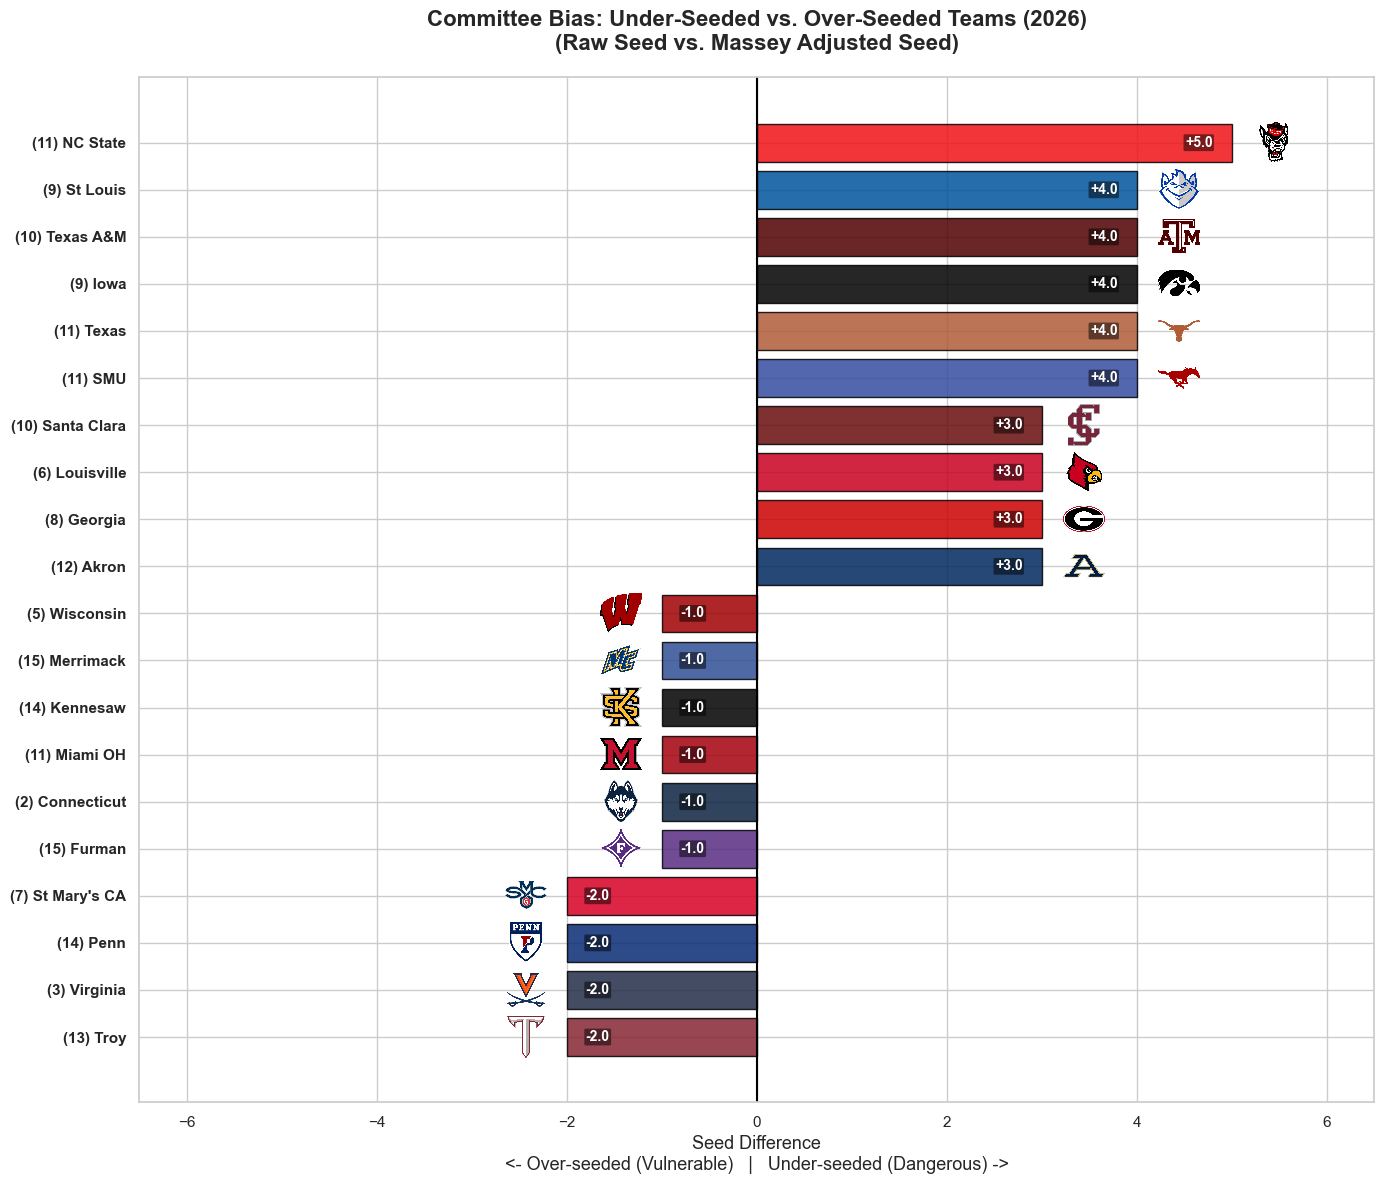

In [7]:
# ==========================================
# VISUALIZATION: Committee Bias (Seed Adjustment)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import io
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import pandas as pd
import numpy as np

# 1. Data Preparation
seed_bias_work_df, seed_bias_base_df, seed_bias_demo_season = build_visual_base_df(
    required_cols=["SeedNum", "Adj_Seed"],
    min_games=10,
    prefer_season=2026,
)

# Calculate the Seed Adjustment
# Positive = Under-seeded sleeper (Committee Seed > Math Seed)
# Negative = Over-seeded fraud (Committee Seed < Math Seed)
seed_bias_base_df["seed_diff"] = seed_bias_base_df["SeedNum"] - seed_bias_base_df["Adj_Seed"]

seed_bias_top_10 = seed_bias_base_df.nlargest(10, "seed_diff")
seed_bias_bottom_10 = seed_bias_base_df.nsmallest(10, "seed_diff")
seed_bias_plot_df = pd.concat([seed_bias_top_10, seed_bias_bottom_10]).sort_values("seed_diff")

# 2. Color Preparation
seed_bias_plot_df["primary_color"] = seed_bias_plot_df.get(
    "TeamColor", pd.Series(dtype=str)
).apply(lambda x: format_hex_color(x, "#4682b4"))

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(14, 12))
sns.set_theme(style="whitegrid")

y_positions = np.arange(len(seed_bias_plot_df))
bars = ax.barh(
    y_positions,
    seed_bias_plot_df["seed_diff"],
    color=seed_bias_plot_df["primary_color"],
    alpha=0.85,
    edgecolor="black",
)

ytick_labels = [
    f"({int(row['SeedNum'])}) {row['TeamName']}"
    for _, row in seed_bias_plot_df.iterrows()
]
ax.set_yticks(y_positions)
ax.set_yticklabels(ytick_labels, fontweight="bold")

plt.title(
    f"Committee Bias: Under-Seeded vs. Over-Seeded Teams ({seed_bias_demo_season})\n"
    "(Raw Seed vs. Massey Adjusted Seed)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel(
    "Seed Difference\n<- Over-seeded (Vulnerable)   |   Under-seeded (Dangerous) ->",
    fontsize=13,
)

ax.axvline(x=0, color="black", linewidth=1.5, linestyle="-")

max_abs_val = seed_bias_plot_df["seed_diff"].abs().max()
x_bound = max(max_abs_val * 1.3, 3.0)
ax.set_xlim(-x_bound, x_bound)

# 4. Logo Placement Logic
for idx, (bar, (_, row)) in enumerate(zip(bars, seed_bias_plot_df.iterrows())):
    val = row["seed_diff"]
    logo_url = row.get("TeamLogo", None)

    if pd.notna(logo_url) and str(logo_url).startswith("http"):
        try:
            req = urllib.request.Request(logo_url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=2) as response:
                img = Image.open(io.BytesIO(response.read())).convert("RGBA")

            imagebox = OffsetImage(img, zoom=0.065)
            x_offset = val + (0.2 if val > 0 else -0.2)
            ab = AnnotationBbox(
                imagebox,
                (x_offset, idx),
                frameon=False,
                pad=0,
                box_alignment=(0 if val > 0 else 1, 0.5),
            )
            ax.add_artist(ab)
        except Exception:
            pass

    text_x = val - (0.2 if val > 0 else -0.2)
    ha = "right" if val > 0 else "left"
    ax.annotate(
        f"{val:+.1f}",
        (text_x, idx),
        va="center",
        ha=ha,
        color="white",
        fontweight="bold",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.1", fc="black", ec="none", alpha=0.5),
    )

plt.tight_layout()
plt.show()

Bracket-eligible team pool: 68 teams across 4 play-in seed slots.


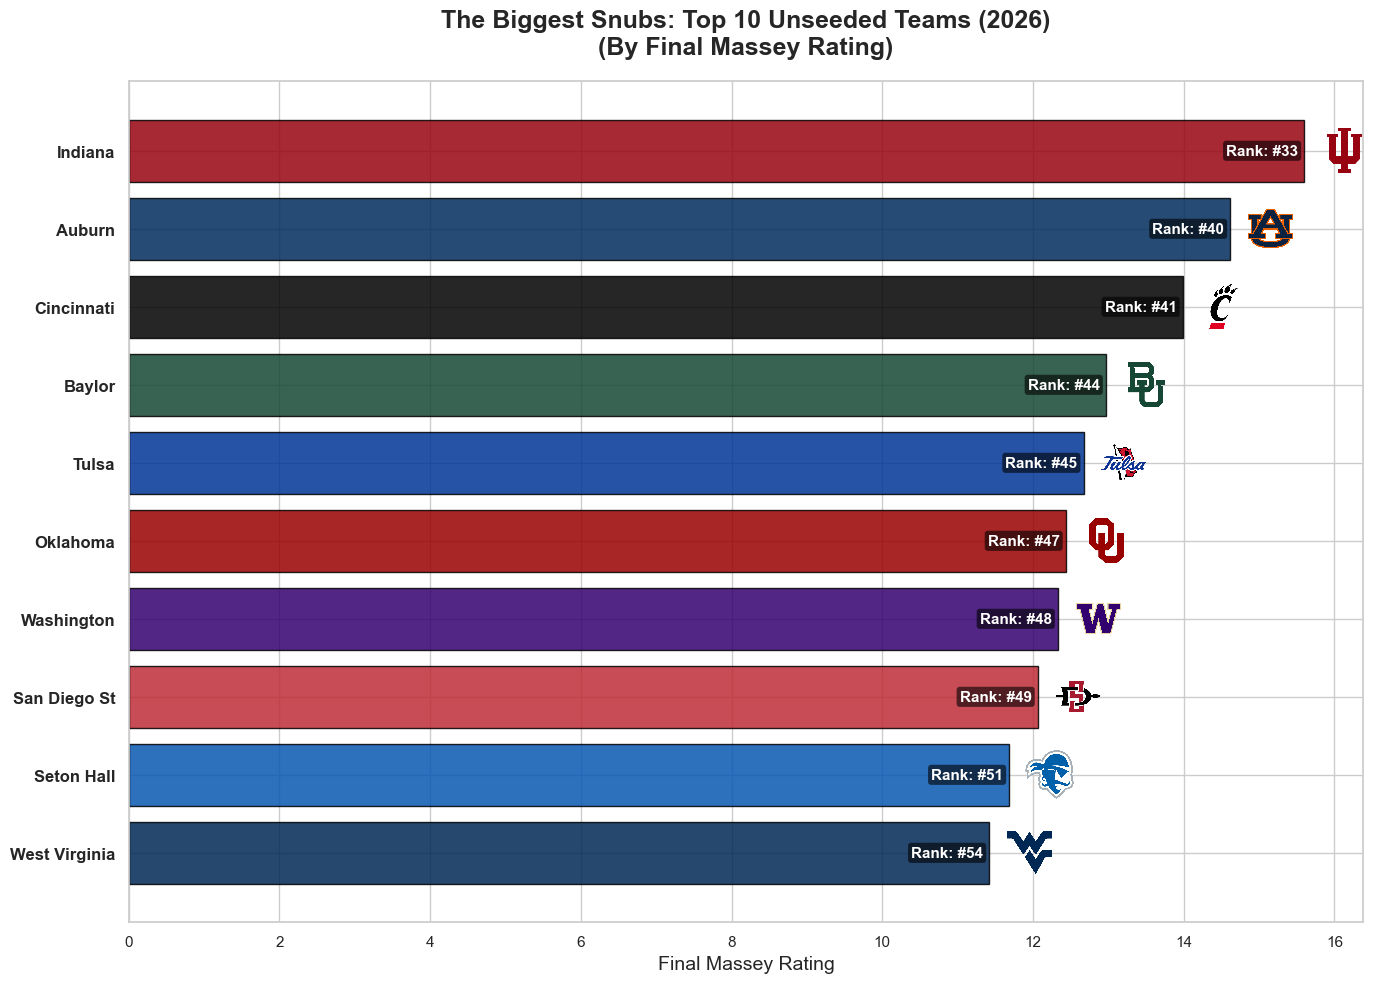

In [8]:
# ==========================================
# VISUALIZATION: Biggest Snubs (Top Unseeded Teams)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import io
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import pandas as pd
import numpy as np

# 1. Data Preparation
snubs_work_df = get_or_load_team_agg().copy()
snubs_work_df["Season_num"] = pd.to_numeric(snubs_work_df["Season"], errors="coerce")

season_counts = snubs_work_df.groupby("Season_num").size()
if season_counts.empty:
    raise RuntimeError("No season data available.")

snubs_demo_season = 2026 if 2026 in season_counts.index else int(season_counts.index.max())
snubs_season_df = snubs_work_df[snubs_work_df["Season_num"] == snubs_demo_season].copy()

if snubs_season_df.empty:
    raise RuntimeError(f"No team rows found for season {snubs_demo_season}.")

eligible_pool = build_tourney_eligible_pool(snubs_demo_season)
eligible_team_ids = set(eligible_pool["TeamID"].astype(int).tolist())

if not eligible_team_ids:
    raise RuntimeError("No bracket-eligible team IDs found in first-round candidate data.")

play_in_slot_count = int(
    eligible_pool.groupby(["Region", "SeedNum"]).size().gt(1).sum()
)
print(
    f"Bracket-eligible team pool: {len(eligible_team_ids)} teams "
    f"across {play_in_slot_count} play-in seed slots."
)

if "TeamID" not in snubs_season_df.columns:
    raise RuntimeError("`TeamID` is required in team_agg for snub detection.")

snubs_season_df["TeamID_num"] = pd.to_numeric(snubs_season_df["TeamID"], errors="coerce")
snubs_season_df["Final_Massey_num"] = pd.to_numeric(snubs_season_df["Final_Massey"], errors="coerce")
snubs_season_df = snubs_season_df[
    snubs_season_df["TeamID_num"].notna() & snubs_season_df["Final_Massey_num"].notna()
].copy()

snubs_season_df["Massey_Rank"] = snubs_season_df["Final_Massey_num"].rank(
    ascending=False, method="min"
)

unseeded_df = snubs_season_df[
    ~snubs_season_df["TeamID_num"].astype(int).isin(eligible_team_ids)
].copy()

top_n = 10
top_snubs = (
    unseeded_df.nsmallest(top_n, "Massey_Rank")
    .sort_values("Final_Massey_num", ascending=True)
    .copy()
)

if top_snubs.empty:
    print(f"No unseeded teams found for season {snubs_demo_season}.")
else:
    # Reuse shared helper defined earlier in the notebook.
    top_snubs["primary_color"] = top_snubs.get("TeamColor", pd.Series(dtype=str)).apply(
        lambda x: format_hex_color(x, "#4682b4")
    )

    fig, ax = plt.subplots(figsize=(14, 10))
    sns.set_theme(style="whitegrid")

    y_positions = np.arange(len(top_snubs))
    bars = ax.barh(
        y_positions,
        top_snubs["Final_Massey_num"],
        color=top_snubs["primary_color"],
        alpha=0.85,
        edgecolor="black",
    )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(top_snubs["TeamName"], fontweight="bold", fontsize=12)

    plt.title(
        f"The Biggest Snubs: Top {len(top_snubs)} Unseeded Teams ({snubs_demo_season})\n"
        "(By Final Massey Rating)",
        fontsize=18,
        fontweight="bold",
        pad=20,
    )
    plt.xlabel("Final Massey Rating", fontsize=14)

    min_val = float(top_snubs["Final_Massey_num"].min())
    max_val = float(top_snubs["Final_Massey_num"].max())
    spread = max(max_val - min_val, 1e-6)

    for idx, (_, row) in enumerate(top_snubs.iterrows()):
        val = float(row["Final_Massey_num"])
        rank = int(row["Massey_Rank"])
        logo_url = row.get("TeamLogo", None)

        if pd.notna(logo_url) and str(logo_url).startswith("http"):
            try:
                req = urllib.request.Request(logo_url, headers={"User-Agent": "Mozilla/5.0"})
                with urllib.request.urlopen(req, timeout=2) as response:
                    img = Image.open(io.BytesIO(response.read())).convert("RGBA")

                imagebox = OffsetImage(img, zoom=0.07)
                offset_dist = spread * 0.05
                ab = AnnotationBbox(
                    imagebox,
                    (val + offset_dist, idx),
                    frameon=False,
                    pad=0,
                    box_alignment=(0, 0.5),
                )
                ax.add_artist(ab)
            except Exception:
                pass

        text_x = val - (spread * 0.02)
        ax.annotate(
            f"Rank: #{rank}",
            (text_x, idx),
            va="center",
            ha="right",
            color="white",
            fontweight="bold",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.2", fc="black", ec="none", alpha=0.6),
        )

    plt.tight_layout()
    plt.show()

Evaluated 36 first-round candidate rows; found 5 upset-edge matchups.


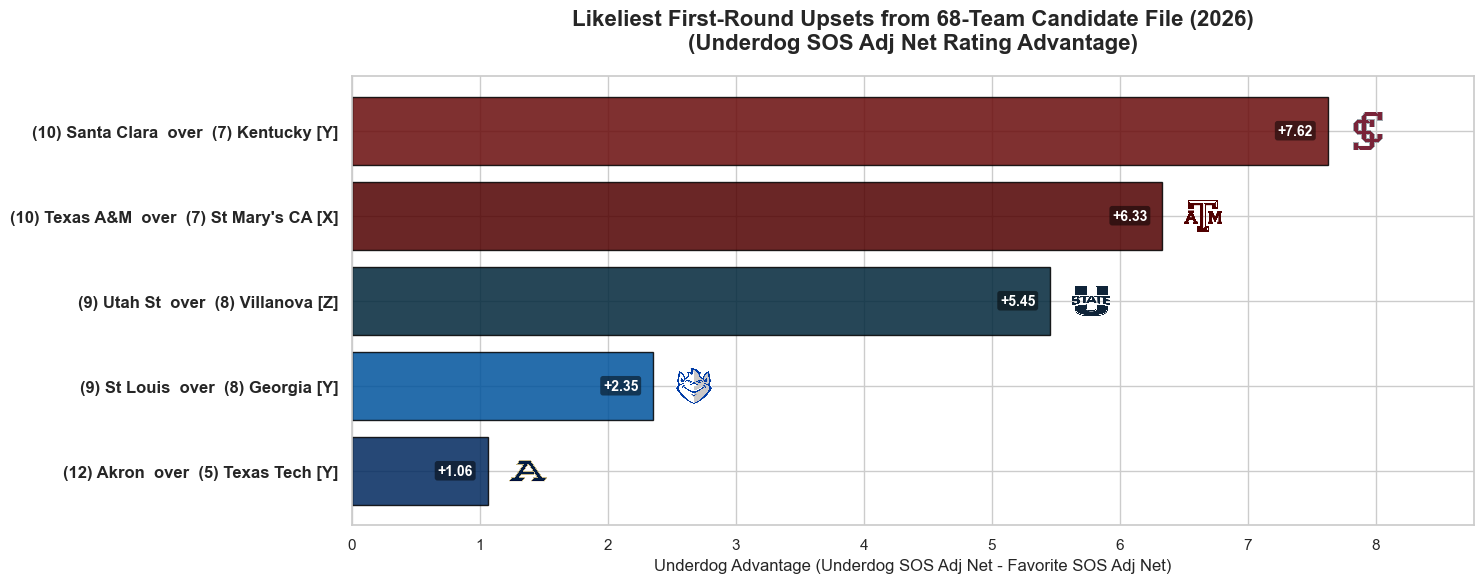

In [9]:
# ==========================================
# VISUALIZATION: Likeliest Upsets (By SOS Adj Net Rating)
# ==========================================
# Uses ONLY first-round 68-team candidate matchups from the exported file.
# Upset edge = underdog SOS Adj Net Rating advantage over the favorite.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import io
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


def format_hex_color(c, default="#4682b4"):
    if pd.isna(c) or not str(c).strip():
        return default
    c_str = str(c).strip()
    if not c_str.startswith("#"):
        if len(c_str) in [3, 6, 8]:
            return "#" + c_str
        return default
    return c_str


def as_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    text = series.astype(str).str.strip().str.lower()
    return text.isin({"true", "1", "yes", "y"})


def get_upsets_by_sos_net(season=2026):
    first_round_df = get_first_round_candidates(season).copy()

    required_cols = [
        "Region",
        "FavoriteTeam",
        "UnderdogTeam",
        "FavoriteSeed",
        "UnderdogSeed",
        "FavoriteMatchesModelTeam1",
        "Model_Diff_sos_adj_net_rating",
        "Model_Team1_Color",
        "Model_Team2_Color",
        "Model_Team1_Logo",
        "Model_Team2_Logo",
    ]
    missing_cols = [c for c in required_cols if c not in first_round_df.columns]
    if missing_cols:
        raise RuntimeError("Missing first-round matchup columns: " + ", ".join(missing_cols))

    first_round_df["FavoriteSeed"] = pd.to_numeric(first_round_df["FavoriteSeed"], errors="coerce")
    first_round_df["UnderdogSeed"] = pd.to_numeric(first_round_df["UnderdogSeed"], errors="coerce")
    first_round_df["Model_Diff_sos_adj_net_rating"] = pd.to_numeric(
        first_round_df["Model_Diff_sos_adj_net_rating"], errors="coerce"
    )
    first_round_df["FavoriteMatchesModelTeam1"] = as_bool(first_round_df["FavoriteMatchesModelTeam1"])

    first_round_df = first_round_df.dropna(
        subset=["FavoriteSeed", "UnderdogSeed", "Model_Diff_sos_adj_net_rating"]
    ).copy()
    if first_round_df.empty:
        return pd.DataFrame()

    first_round_df["FavoriteSeed"] = first_round_df["FavoriteSeed"].astype(int)
    first_round_df["UnderdogSeed"] = first_round_df["UnderdogSeed"].astype(int)

    # Model_Diff_sos_adj_net_rating is Team1 - Team2 in the modeled row.
    # Convert to underdog - favorite using FavoriteMatchesModelTeam1 orientation.
    first_round_df["Rating_Diff"] = np.where(
        first_round_df["FavoriteMatchesModelTeam1"],
        -first_round_df["Model_Diff_sos_adj_net_rating"],
        first_round_df["Model_Diff_sos_adj_net_rating"],
    )

    first_round_df["Underdog_Color"] = np.where(
        first_round_df["FavoriteMatchesModelTeam1"],
        first_round_df["Model_Team2_Color"],
        first_round_df["Model_Team1_Color"],
    )
    first_round_df["Underdog_Logo"] = np.where(
        first_round_df["FavoriteMatchesModelTeam1"],
        first_round_df["Model_Team2_Logo"],
        first_round_df["Model_Team1_Logo"],
    )

    upset_df = first_round_df[first_round_df["Rating_Diff"] > 0].copy()
    if upset_df.empty:
        return pd.DataFrame()

    return upset_df[
        [
            "Region",
            "FavoriteTeam",
            "FavoriteSeed",
            "UnderdogTeam",
            "UnderdogSeed",
            "Rating_Diff",
            "Underdog_Color",
            "Underdog_Logo",
        ]
    ].copy()


# Generate list for demo season using FIRST-ROUND ONLY file
demo_season = 2026
all_first_round_rows = len(get_first_round_candidates(demo_season))
rating_upsets = get_upsets_by_sos_net(demo_season)

if rating_upsets.empty:
    print(
        f"Evaluated {all_first_round_rows:,} first-round candidate rows for {demo_season}; "
        "no SOS Adj Net upset edges found."
    )
else:
    rating_upsets = rating_upsets.sort_values("Rating_Diff", ascending=True).reset_index(drop=True)

    print(
        f"Evaluated {all_first_round_rows:,} first-round candidate rows; "
        f"found {len(rating_upsets):,} upset-edge matchups."
    )

    rating_upsets["primary_color"] = rating_upsets["Underdog_Color"].apply(
        lambda x: format_hex_color(x, "#e74c3c")
    )

    rating_upsets["Display_Label"] = (
        "(" + rating_upsets["UnderdogSeed"].astype(str) + ") "
        + rating_upsets["UnderdogTeam"]
        + "  over  ("
        + rating_upsets["FavoriteSeed"].astype(str)
        + ") "
        + rating_upsets["FavoriteTeam"]
        + " ["
        + rating_upsets["Region"].astype(str)
        + "]"
    )

    fig, ax = plt.subplots(figsize=(15, max(6, len(rating_upsets) * 0.75)))
    sns.set_theme(style="whitegrid")

    y_positions = np.arange(len(rating_upsets))
    bars = ax.barh(
        y_positions,
        rating_upsets["Rating_Diff"],
        color=rating_upsets["primary_color"],
        alpha=0.85,
        edgecolor="black",
    )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(rating_upsets["Display_Label"], fontweight="bold", fontsize=12)

    plt.title(
        f"Likeliest First-Round Upsets from 68-Team Candidate File ({demo_season})\n"
        "(Underdog SOS Adj Net Rating Advantage)",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )
    plt.xlabel("Underdog Advantage (Underdog SOS Adj Net - Favorite SOS Adj Net)", fontsize=12)

    max_val = max(float(rating_upsets["Rating_Diff"].max()), 1e-6)
    ax.set_xlim(0, max_val * 1.15)

    for idx, (bar, (_, row)) in enumerate(zip(bars, rating_upsets.iterrows())):
        val = row["Rating_Diff"]
        logo_url = row.get("Underdog_Logo", None)

        if pd.notna(logo_url) and str(logo_url).startswith("http"):
            try:
                req = urllib.request.Request(logo_url, headers={"User-Agent": "Mozilla/5.0"})
                with urllib.request.urlopen(req, timeout=2) as response:
                    img = Image.open(io.BytesIO(response.read())).convert("RGBA")

                imagebox = OffsetImage(img, zoom=0.06)
                offset = max_val * 0.02
                ab = AnnotationBbox(
                    imagebox,
                    (val + offset, idx),
                    frameon=False,
                    pad=0,
                    box_alignment=(0, 0.5),
                )
                ax.add_artist(ab)
            except Exception:
                pass

        ax.annotate(
            f"+{val:.2f}",
            (val - (max_val * 0.015), idx),
            va="center",
            ha="right",
            color="white",
            fontweight="bold",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.2", fc="black", ec="none", alpha=0.5),
        )

    plt.tight_layout()
    plt.show()

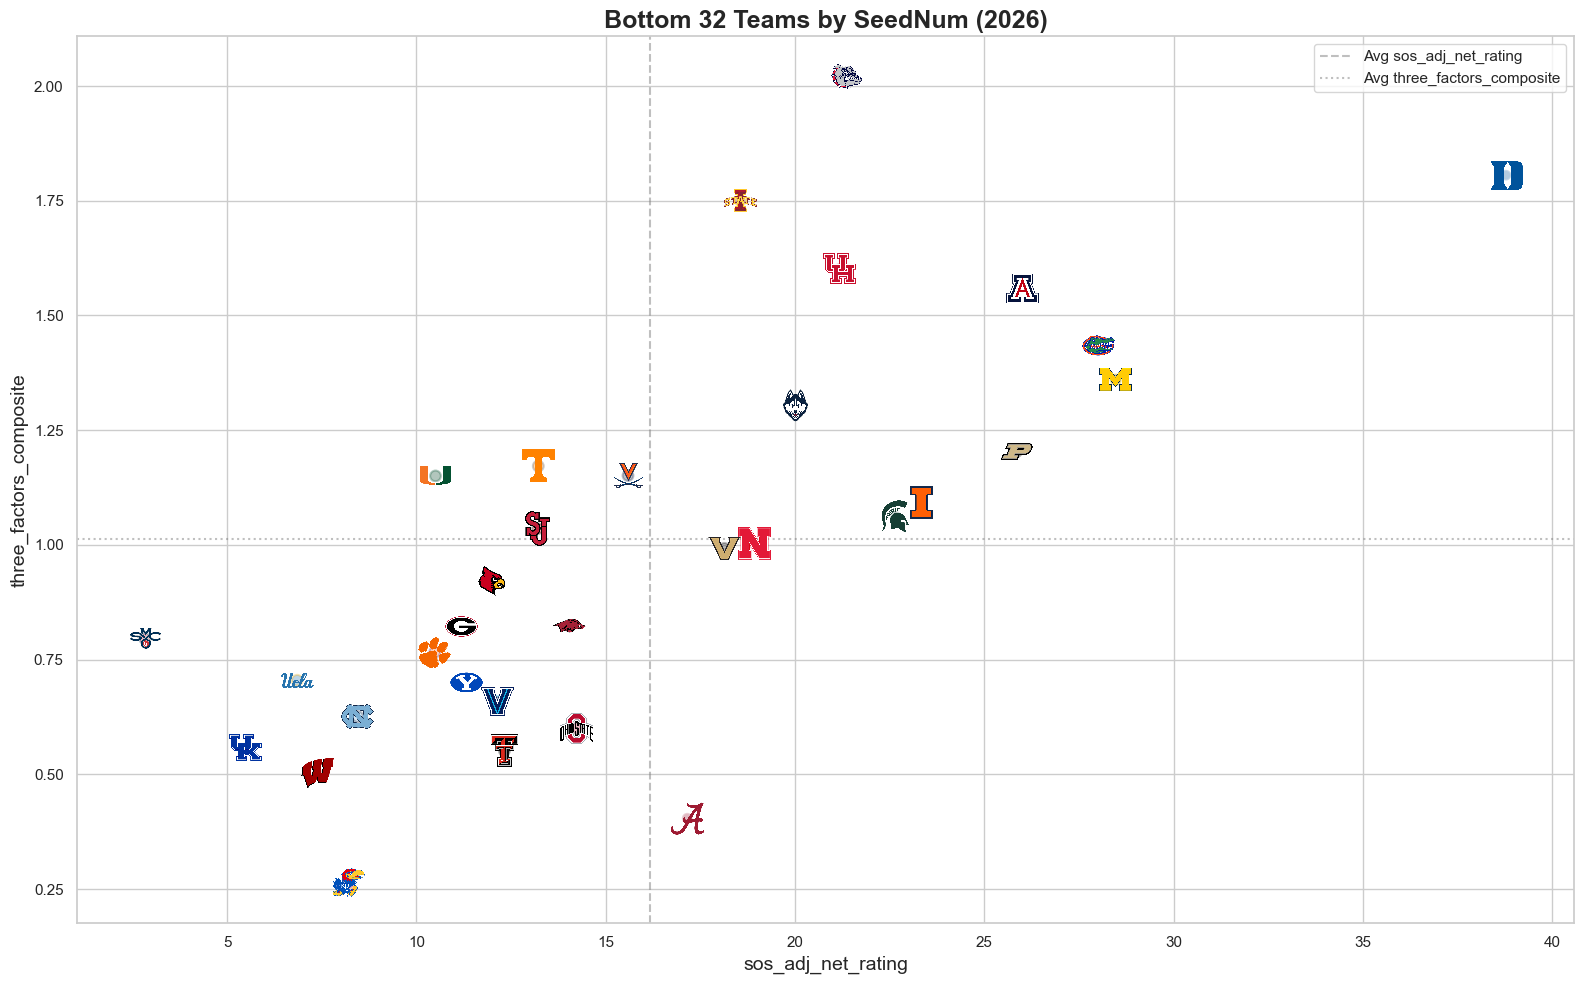

In [15]:
# ==========================================
# VISUALIZATION: Custom Team Explorer
# ==========================================

def plot_custom_team_scatter(x_metric, y_metric, sort_metric, top_n=40, sort_order="Top"):
    """
    Plots a dynamic scatter plot of teams with their logos based on custom metrics.

    Parameters:
    -----------
    x_metric : str - The column name to plot on the X-axis
    y_metric : str - The column name to plot on the Y-axis
    sort_metric : str - The column name used to rank the teams
    top_n : int - How many teams to include in the plot
    sort_order : str - 'Top' or 'Bottom'
    """

    _, scatter_base_df, scatter_demo_season = build_visual_base_df(
        required_cols=[x_metric, y_metric, sort_metric],
        min_games=10,
        prefer_season=2026,
    )

    plot_df = scatter_base_df.dropna(subset=[x_metric, y_metric, sort_metric]).copy()
    if plot_df.empty:
        print(f"No data available for: {x_metric}, {y_metric}, {sort_metric}.")
        return

    ascending = True if sort_order.title() == "Bottom" else False
    plot_df = plot_df.sort_values(by=sort_metric, ascending=ascending).head(top_n)

    # Reuse shared helper defined earlier in the notebook.
    plot_df["primary_color"] = plot_df.get("TeamColor", pd.Series(dtype=str)).apply(
        lambda x: format_hex_color(x, "#4682b4")
    )
    plot_df["secondary_color"] = plot_df.get("TeamAlternateColor", pd.Series(dtype=str)).apply(
        lambda x: format_hex_color(x, "#000000")
    )

    fig, ax = plt.subplots(figsize=(16, 10))
    sns.set_theme(style="whitegrid")

    ax.scatter(
        plot_df[x_metric],
        plot_df[y_metric],
        c=plot_df["primary_color"],
        edgecolors=plot_df["secondary_color"],
        alpha=0.3,
        s=60,
        linewidths=1.5,
    )

    plt.title(
        f"{sort_order.title()} {top_n} Teams by {sort_metric} ({scatter_demo_season})",
        fontsize=18,
        fontweight="bold",
    )
    plt.xlabel(x_metric, fontsize=14)
    plt.ylabel(y_metric, fontsize=14)

    plt.axvline(
        x=plot_df[x_metric].mean(),
        color="gray",
        linestyle="--",
        alpha=0.5,
        label=f"Avg {x_metric}",
    )
    plt.axhline(
        y=plot_df[y_metric].mean(),
        color="gray",
        linestyle=":",
        alpha=0.5,
        label=f"Avg {y_metric}",
    )
    plt.legend(loc="best")

    def annotate_with_logo(ax, row):
        x, y = row[x_metric], row[y_metric]
        team_name = row.get("TeamName", "Unknown")
        logo_url = row.get("TeamLogo", None)

        logo_added = False
        if pd.notna(logo_url) and str(logo_url).startswith("http"):
            try:
                req = urllib.request.Request(logo_url, headers={"User-Agent": "Mozilla/5.0"})
                with urllib.request.urlopen(req, timeout=2) as response:
                    img = Image.open(io.BytesIO(response.read())).convert("RGBA")

                zoom_factor = 0.08 if top_n <= 25 else 0.05
                imagebox = OffsetImage(img, zoom=zoom_factor)
                ab = AnnotationBbox(imagebox, (x, y), frameon=False, pad=0)
                ax.add_artist(ab)
                logo_added = True
            except Exception:
                pass

        if not logo_added:
            ax.annotate(
                team_name,
                (x, y),
                xytext=(0, 0),
                textcoords="offset points",
                fontsize=8,
                fontweight="bold",
                ha="center",
                va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.9),
            )

    for _, row in plot_df.iterrows():
        annotate_with_logo(ax, row)

    plt.tight_layout()
    plt.show()

# ==========================================
# Configuration (edit values below)
# ==========================================
X_AXIS_METRIC = "sos_adj_net_rating"
Y_AXIS_METRIC = "three_factors_composite"
SORT_BY_METRIC = "SeedNum"

NUMBER_OF_TEAMS = 32
SHOW_TOP_OR_BOTTOM = "Bottom"

plot_custom_team_scatter(
    x_metric=X_AXIS_METRIC,
    y_metric=Y_AXIS_METRIC,
    sort_metric=SORT_BY_METRIC,
    top_n=NUMBER_OF_TEAMS,
    sort_order=SHOW_TOP_OR_BOTTOM,
)

In [11]:
target_col = "Target_Team1Win"
diff_cols = [c for c in matchups.columns if c.startswith("Diff_")]

if not diff_cols:
    raise RuntimeError("No Diff_* columns found for modeling.")

model_df = matchups.dropna(subset=[target_col]).copy()
X = model_df[diff_cols]
y = pd.to_numeric(model_df[target_col], errors="coerce").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

logreg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=42)),
])
logreg.fit(X_train, y_train)
pred_proba = logreg.predict_proba(X_test)[:, 1]
pred_label = (pred_proba >= 0.5).astype(int)

print("Logistic Regression Demo")
print(f"AUC: {roc_auc_score(y_test, pred_proba):.3f}")
print(f"Accuracy: {accuracy_score(y_test, pred_label):.3f}")

Logistic Regression Demo
AUC: 0.672
Accuracy: 0.686


In [12]:
try:
    from xgboost import XGBClassifier
except Exception as exc:
    print(f"XGBoost unavailable: {exc}")
    XGBClassifier = None

if XGBClassifier is not None:
    xgb_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=42,
        )),
    ])

    xgb_pipe.fit(X_train, y_train)
    xgb_proba = xgb_pipe.predict_proba(X_test)[:, 1]
    xgb_pred = (xgb_proba >= 0.5).astype(int)

    print("XGBoost Demo")
    print(f"AUC: {roc_auc_score(y_test, xgb_proba):.3f}")
    print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.3f}")
else:
    print("Install xgboost to run this cell: pip install xgboost")

XGBoost Demo
AUC: 0.648
Accuracy: 0.665


In [13]:
# ==========================================
# 2026 MATCHUP PREP (MODEL SELECTABLE)
# ==========================================
import numpy as np
import pandas as pd

# Student choices
selected_model_name = "logreg"  # options: "logreg", "xgboost" (if available)
sim_season = 2026
RANDOM_STATE = 42
N_SIMS = 10000
ROUND1_PAIRS = [(1, 16), (8, 9), (5, 12), (4, 13), (6, 11), (3, 14), (7, 10), (2, 15)]

# Build available model dictionary from previous cells.
# Contract for simulation: model must implement predict_proba(X) and return class-1 probabilities.
available_models = {}
if "logreg" in globals() and hasattr(logreg, "predict_proba"):
    available_models["logreg"] = logreg
if "xgb_pipe" in globals() and xgb_pipe is not None and hasattr(xgb_pipe, "predict_proba"):
    available_models["xgboost"] = xgb_pipe

if not available_models:
    raise RuntimeError(
        "No trained model with predict_proba found. Run the logistic/XGBoost training cells first."
    )

if selected_model_name not in available_models:
    raise ValueError(
        f"selected_model_name='{selected_model_name}' is unavailable. "
        f"Available models: {sorted(available_models.keys())}"
    )

selected_model = available_models[selected_model_name]
print(f"Using model for simulation: {selected_model_name}")

# Use shared all-possible matchup CSV path from setup cell.
if "matchups_2026_all_path" not in globals():
    raise RuntimeError("`matchups_2026_all_path` not found. Run the setup/data-load cell first.")

if not matchups_2026_all_path.exists():
    raise FileNotFoundError(
        f"Could not find `{matchups_2026_all_path}`. Run Data_Prep export cells first."
    )

if "matchups_2026_all" in globals() and isinstance(matchups_2026_all, pd.DataFrame) and not matchups_2026_all.empty:
    matchup_prob_2026_df = matchups_2026_all.copy()
else:
    print(f"Loading all-possible 2026 matchups from {matchups_2026_all_path}...")
    matchup_prob_2026_df = pd.read_csv(matchups_2026_all_path)

if matchup_prob_2026_df.empty:
    raise RuntimeError("Loaded 2026 all-possible matchup dataset is empty.")

if "diff_cols" not in globals() or not diff_cols:
    raise RuntimeError("`diff_cols` not found. Run the baseline modeling cell first.")

missing_diff_cols = [c for c in diff_cols if c not in matchup_prob_2026_df.columns]
if missing_diff_cols:
    raise RuntimeError(
        "2026 all-possible file is missing required Diff_* columns:\n"
        + "\n".join(missing_diff_cols)
    )

matchup_prob_2026_df["TeamA"] = pd.to_numeric(matchup_prob_2026_df["Team1ID"], errors="coerce")
matchup_prob_2026_df["TeamB"] = pd.to_numeric(matchup_prob_2026_df["Team2ID"], errors="coerce")
matchup_prob_2026_df = matchup_prob_2026_df.dropna(subset=["TeamA", "TeamB"]).copy()
matchup_prob_2026_df["TeamA"] = matchup_prob_2026_df["TeamA"].astype(int)
matchup_prob_2026_df["TeamB"] = matchup_prob_2026_df["TeamB"].astype(int)

X_2026 = matchup_prob_2026_df[diff_cols].copy()
pred_probs = selected_model.predict_proba(X_2026)[:, 1]

if not np.isfinite(pred_probs).all():
    raise RuntimeError("Model produced non-finite probabilities for 2026 matchups.")
if (pred_probs < 0).any() or (pred_probs > 1).any():
    raise RuntimeError("Model produced probabilities outside [0, 1].")

matchup_prob_2026_df["TeamA_WinProb"] = pred_probs.astype(float)

# Add reverse-direction rows so probability lookup works in either team order.
reverse_df = matchup_prob_2026_df.copy()
reverse_df["TeamA"] = matchup_prob_2026_df["TeamB"].values
reverse_df["TeamB"] = matchup_prob_2026_df["TeamA"].values
reverse_df["TeamA_WinProb"] = 1.0 - matchup_prob_2026_df["TeamA_WinProb"].values

matchup_prob_2026_df = pd.concat([matchup_prob_2026_df, reverse_df], ignore_index=True)
matchup_prob_2026_df = matchup_prob_2026_df.drop_duplicates(subset=["TeamA", "TeamB"], keep="first")

matchup_prob_lookup_2026 = {
    (int(row.TeamA), int(row.TeamB)): float(row.TeamA_WinProb)
    for row in matchup_prob_2026_df[["TeamA", "TeamB", "TeamA_WinProb"]].itertuples(index=False)
}

# Build first-round rows from the precomputed 68-team candidate file.
first_round_predictions_2026 = get_first_round_candidates(sim_season).copy()
required_first_round_cols = [
    "Region",
    "FavoriteSeed",
    "UnderdogSeed",
    "FavoriteTeamID",
    "UnderdogTeamID",
]
missing_first_round_cols = [c for c in required_first_round_cols if c not in first_round_predictions_2026.columns]
if missing_first_round_cols:
    raise RuntimeError(
        "First-round candidate file is missing required columns: " + ", ".join(missing_first_round_cols)
    )

for col in ["FavoriteSeed", "UnderdogSeed", "FavoriteTeamID", "UnderdogTeamID"]:
    first_round_predictions_2026[col] = pd.to_numeric(first_round_predictions_2026[col], errors="coerce")

first_round_predictions_2026 = first_round_predictions_2026.dropna(
    subset=["Region", "FavoriteSeed", "UnderdogSeed", "FavoriteTeamID", "UnderdogTeamID"]
).copy()
first_round_predictions_2026["Region"] = first_round_predictions_2026["Region"].astype(str).str.upper().str.strip()
first_round_predictions_2026["FavoriteSeed"] = first_round_predictions_2026["FavoriteSeed"].astype(int)
first_round_predictions_2026["UnderdogSeed"] = first_round_predictions_2026["UnderdogSeed"].astype(int)
first_round_predictions_2026["FavoriteTeamID"] = first_round_predictions_2026["FavoriteTeamID"].astype(int)
first_round_predictions_2026["UnderdogTeamID"] = first_round_predictions_2026["UnderdogTeamID"].astype(int)

# Seed slot candidates are now derived from first-round rows (guarantees 68-team coverage).
region_seed_slot_candidates_2026 = {}
for row in first_round_predictions_2026.itertuples(index=False):
    region_seed_slot_candidates_2026.setdefault(row.Region, {}).setdefault(row.FavoriteSeed, set()).add(row.FavoriteTeamID)
    region_seed_slot_candidates_2026.setdefault(row.Region, {}).setdefault(row.UnderdogSeed, set()).add(row.UnderdogTeamID)

region_seed_slot_candidates_2026 = {
    region: {seed_num: sorted(team_ids) for seed_num, team_ids in seed_map.items()}
    for region, seed_map in region_seed_slot_candidates_2026.items()
}

if not region_seed_slot_candidates_2026:
    raise RuntimeError("No valid seed slots found in first-round candidate data.")

# Build TeamID -> TeamName lookup for plotting and tables.
team_name_map = {}
if "team_agg" in globals() and {"TeamID", "TeamName", "Season"}.issubset(team_agg.columns):
    names_df = team_agg[["TeamID", "TeamName", "Season"]].copy()
    names_df["TeamID"] = pd.to_numeric(names_df["TeamID"], errors="coerce")
    names_df["Season"] = pd.to_numeric(names_df["Season"], errors="coerce")
    names_df = names_df.dropna(subset=["TeamID", "TeamName", "Season"]).sort_values(["TeamID", "Season"])
    team_name_map = names_df.drop_duplicates(subset=["TeamID"], keep="last").set_index("TeamID")["TeamName"].to_dict()

first_round_predictions_2026["FavoriteTeam"] = first_round_predictions_2026["FavoriteTeamID"].map(
    lambda tid: team_name_map.get(tid, f"Team {tid}")
)
first_round_predictions_2026["UnderdogTeam"] = first_round_predictions_2026["UnderdogTeamID"].map(
    lambda tid: team_name_map.get(tid, f"Team {tid}")
)
first_round_predictions_2026["FavoriteWinProb"] = first_round_predictions_2026.apply(
    lambda r: float(matchup_prob_lookup_2026.get((int(r["FavoriteTeamID"]), int(r["UnderdogTeamID"])), 0.5)),
    axis=1,
)
first_round_predictions_2026["UpsetProb"] = 1.0 - first_round_predictions_2026["FavoriteWinProb"]

first_round_predictions_2026 = first_round_predictions_2026[
    [
        "Region",
        "FavoriteSeed",
        "UnderdogSeed",
        "FavoriteTeamID",
        "UnderdogTeamID",
        "FavoriteTeam",
        "UnderdogTeam",
        "FavoriteWinProb",
        "UpsetProb",
    ]
].sort_values(["Region", "FavoriteSeed", "FavoriteTeam", "UnderdogTeam"]).reset_index(drop=True)

# Seed lookup table used later for results display.
seed_lookup_df = pd.concat(
    [
        first_round_predictions_2026[["FavoriteTeamID", "Region", "FavoriteSeed"]].rename(
            columns={"FavoriteTeamID": "TeamID", "FavoriteSeed": "SeedNum"}
        ),
        first_round_predictions_2026[["UnderdogTeamID", "Region", "UnderdogSeed"]].rename(
            columns={"UnderdogTeamID": "TeamID", "UnderdogSeed": "SeedNum"}
        ),
    ],
    ignore_index=True,
).drop_duplicates(subset=["TeamID", "Region", "SeedNum"])
seed_lookup_df["Seed"] = seed_lookup_df["Region"] + seed_lookup_df["SeedNum"].astype(str).str.zfill(2)
seeds_df_2026 = seed_lookup_df[["TeamID", "Seed"]].drop_duplicates(subset=["TeamID", "Seed"]).copy()

play_in_count = int(
    sum(len(team_ids) > 1 for seed_map in region_seed_slot_candidates_2026.values() for team_ids in seed_map.values())
)
alt_rows = int(len(first_round_predictions_2026) - 32)

stage_counts = {
    "directed_prob_rows": int(len(matchup_prob_2026_df)),
    "regions": int(len(region_seed_slot_candidates_2026)),
    "seed_slots": int(sum(len(v) for v in region_seed_slot_candidates_2026.values())),
    "eligible_teams": int(len({
        tid
        for seed_map in region_seed_slot_candidates_2026.values()
        for team_ids in seed_map.values()
        for tid in team_ids
    })),
    "first_round_rows": int(len(first_round_predictions_2026)),
    "play_in_seed_slots": play_in_count,
    "play_in_extra_rows": alt_rows,
}
print(f"Prepared 2026 probability lookup rows: {len(matchup_prob_2026_df):,}")
print(f"Prep summary: {stage_counts}")

display(matchup_prob_2026_df.head(10))
display(first_round_predictions_2026.head(10))

Using model for simulation: logreg
Prepared 2026 probability lookup rows: 4,556
Prep summary: {'directed_prob_rows': 4556, 'regions': 4, 'seed_slots': 64, 'eligible_teams': 68, 'first_round_rows': 36, 'play_in_seed_slots': 4, 'play_in_extra_rows': 4}


,Season,Team1ID,Team2ID,Team1_TeamName,Team2_TeamName,Team1_Seed,Team2_Seed,Team1_SeedRegion,Team2_SeedRegion,Team1_Field68Role,...,Diff_weighted_massey_momentum,Team1_Color,Team1_AlternateColor,Team1_Logo,Team2_Color,Team2_AlternateColor,Team2_Logo,TeamA,TeamB,TeamA_WinProb
0,2026,1181,1112,Duke,Arizona,W01,Z01,W,Z,primary,...,0.233461,00539b,ffffff,https://a.espncdn.com/i/teamlogos/ncaa/500/150...,0c234b,003366,https://a.espncdn.com/i/teamlogos/ncaa/500/12.png,1181,1112,0.705628
1,2026,1112,1196,Arizona,Florida,Z01,X01,Z,X,primary,...,-0.330847,0c234b,003366,https://a.espncdn.com/i/teamlogos/ncaa/500/12.png,0021a5,fa4616,https://a.espncdn.com/i/teamlogos/ncaa/500/57.png,1112,1196,0.321656
2,2026,1276,1112,Michigan,Arizona,Y01,Z01,Y,Z,primary,...,0.006314,00274c,ffcb05,https://a.espncdn.com/i/teamlogos/ncaa/500/130...,0c234b,003366,https://a.espncdn.com/i/teamlogos/ncaa/500/12.png,1276,1112,0.648263
3,2026,1112,1163,Arizona,Connecticut,Z01,W02,Z,W,primary,...,0.185785,0c234b,003366,https://a.espncdn.com/i/teamlogos/ncaa/500/12.png,0c2340,a2aaad,https://a.espncdn.com/i/teamlogos/ncaa/500/41.png,1112,1163,0.577422
4,2026,1112,1222,Arizona,Houston,Z01,X02,Z,X,primary,...,-0.038515,0c234b,003366,https://a.espncdn.com/i/teamlogos/ncaa/500/12.png,c8102e,ffffff,https://a.espncdn.com/i/teamlogos/ncaa/500/248...,1112,1222,0.481188
5,2026,1112,1235,Arizona,Iowa St,Z01,Y02,Z,Y,primary,...,0.410111,0c234b,003366,https://a.espncdn.com/i/teamlogos/ncaa/500/12.png,822433,fdca2f,https://a.espncdn.com/i/teamlogos/ncaa/500/66.png,1112,1235,0.540642
6,2026,1112,1345,Arizona,Purdue,Z01,Z02,Z,Z,primary,...,0.133833,0c234b,003366,https://a.espncdn.com/i/teamlogos/ncaa/500/12.png,000000,000000,https://a.espncdn.com/i/teamlogos/ncaa/500/250...,1112,1345,0.532594
7,2026,1112,1211,Arizona,Gonzaga,Z01,Z03,Z,Z,primary,...,0.078690,0c234b,003366,https://a.espncdn.com/i/teamlogos/ncaa/500/12.png,041e42,c8102e,https://a.espncdn.com/i/teamlogos/ncaa/500/225...,1112,1211,0.448952
8,2026,1112,1228,Arizona,Illinois,Z01,X03,Z,X,primary,...,0.057898,0c234b,003366,https://a.espncdn.com/i/teamlogos/ncaa/500/12.png,ff5f05,13294b,https://a.espncdn.com/i/teamlogos/ncaa/500/356...,1112,1228,0.532646
9,2026,1112,1277,Arizona,Michigan St,Z01,W03,Z,W,primary,...,0.102621,0c234b,003366,https://a.espncdn.com/i/teamlogos/ncaa/500/12.png,173f35,ffffff,https://a.espncdn.com/i/teamlogos/ncaa/500/127...,1112,1277,0.608161


,Region,FavoriteSeed,UnderdogSeed,FavoriteTeamID,UnderdogTeamID,FavoriteTeam,UnderdogTeam,FavoriteWinProb,UpsetProb
0,W,1,16,1181,1373,Duke,Siena,0.985007,0.014993
1,W,2,15,1163,1202,Connecticut,Furman,0.945564,0.054436
2,W,3,14,1277,1295,Michigan St,N Dakota St,0.880586,0.119414
3,W,4,13,1242,1465,Kansas,Cal Baptist,0.797530,0.202470
4,W,5,12,1385,1320,St John's,Northern Iowa,0.687486,0.312514
5,W,6,11,1257,1378,Louisville,South Florida,0.747543,0.252457
6,W,7,10,1417,1416,UCLA,UCF,0.498488,0.501512
7,W,8,9,1326,1395,Ohio St,TCU,0.438604,0.561396
8,X,1,16,1196,1250,Florida,Lehigh,0.997688,0.002312
9,X,1,16,1196,1341,Florida,Prairie View,0.997428,0.002572


Using model for simulation: logreg
Using prepared matchup dataset with 4,556 directed rows.
Completed 1,000/10,000 simulations
Completed 2,000/10,000 simulations
Completed 3,000/10,000 simulations
Completed 4,000/10,000 simulations
Completed 5,000/10,000 simulations
Completed 6,000/10,000 simulations
Completed 7,000/10,000 simulations
Completed 8,000/10,000 simulations
Completed 9,000/10,000 simulations
Completed 10,000/10,000 simulations
Compiling simulation results...
Fallback 50/50 matchup lookups used: 0


,Region,Matchup,FavoriteWinProb,UpsetProb
0,W,(1) Duke vs (16) Siena,0.985007,0.014993
1,W,(2) Connecticut vs (15) Furman,0.945564,0.054436
2,W,(3) Michigan St vs (14) N Dakota St,0.880586,0.119414
3,W,(4) Kansas vs (13) Cal Baptist,0.797530,0.202470
4,W,(5) St John's vs (12) Northern Iowa,0.687486,0.312514
5,W,(6) Louisville vs (11) South Florida,0.747543,0.252457
6,W,(7) UCLA vs (10) UCF,0.498488,0.501512
7,W,(8) Ohio St vs (9) TCU,0.438604,0.561396
8,X,(1) Florida vs (16) Lehigh,0.997688,0.002312
9,X,(1) Florida vs (16) Prairie View,0.997428,0.002572


Top 10 Most Likely Champions


,TeamLabel,Round of 32,Sweet 16,Elite 8,Final 4,Title Game,Champion
0,Duke (W01),0.9828,0.9170,0.8356,0.6871,0.4421,0.3063
1,Michigan (Y01),0.9914,0.8674,0.7536,0.5855,0.3987,0.2064
2,Florida (X01),0.9974,0.8918,0.7975,0.5364,0.2948,0.1782
3,Gonzaga (Z03),0.9639,0.7410,0.4799,0.3106,0.1540,0.0629
4,Arizona (Z01),0.9754,0.8182,0.6413,0.3337,0.1600,0.0593
5,Houston (X02),0.9504,0.8431,0.4926,0.2244,0.0880,0.0400
6,Iowa St (Y02),0.9844,0.7660,0.5145,0.2023,0.0942,0.0321
7,Purdue (Z02),0.9799,0.6647,0.3150,0.1761,0.0761,0.0273
8,Illinois (X03),0.9707,0.7871,0.4247,0.1756,0.0644,0.0272
9,Connecticut (W02),0.9463,0.7648,0.4465,0.1339,0.0467,0.0204


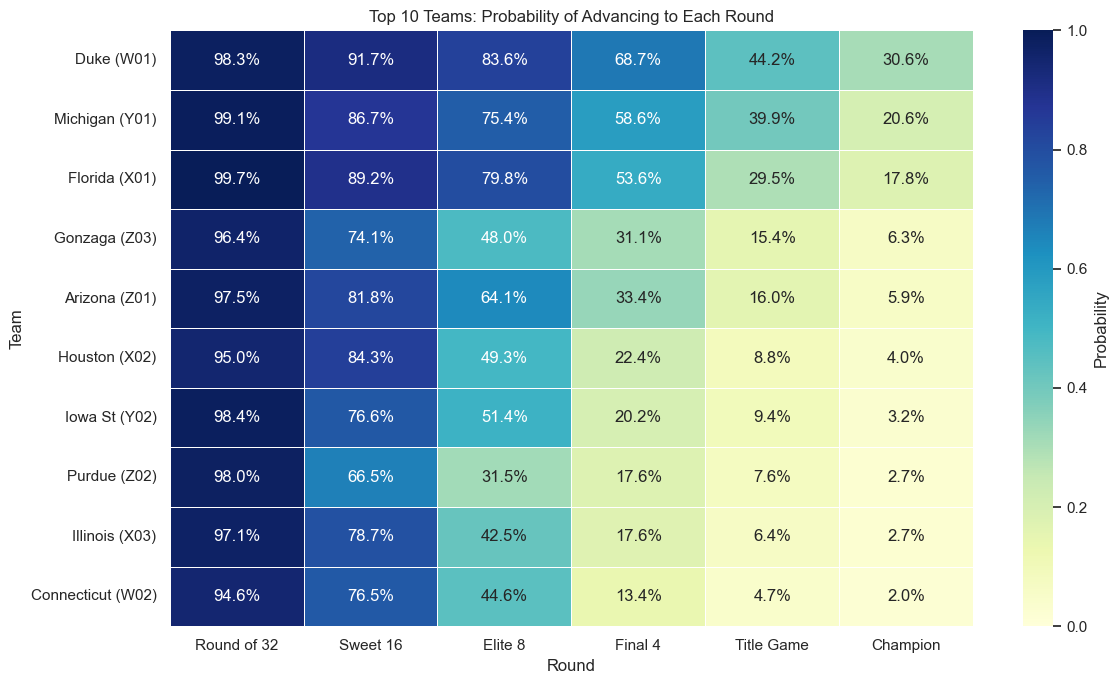

In [14]:
# ==========================================
# MONTE CARLO SIMULATION + VISUALIZATION OUTPUTS
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

required_objects = [
    "matchup_prob_2026_df",
    "matchup_prob_lookup_2026",
    "region_seed_slot_candidates_2026",
    "seeds_df_2026",
    "selected_model_name",
    "first_round_predictions_2026",
]
missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise RuntimeError(
        "Run the 2026 MATCHUP PREP cell first. Missing: " + ", ".join(missing)
    )

print(f"Using model for simulation: {selected_model_name}")
print(f"Using prepared matchup dataset with {len(matchup_prob_2026_df):,} directed rows.")

n_sims = int(globals().get("N_SIMS", 10000))
random_state = int(globals().get("RANDOM_STATE", 42))
np.random.seed(random_state)

round1_pairs = [(1, 16), (8, 9), (5, 12), (4, 13), (6, 11), (3, 14), (7, 10), (2, 15)]

fallback_counter = {"count": 0}

def game_probability(team_a, team_b, probability_lookup, fallback_counter_obj=None):
    p = probability_lookup.get((team_a, team_b))
    if p is not None:
        return float(p)

    p_rev = probability_lookup.get((team_b, team_a))
    if p_rev is not None:
        return float(1.0 - p_rev)

    if fallback_counter_obj is not None:
        fallback_counter_obj["count"] += 1
    return 0.5


def pick_winner(team_a, team_b, probability_lookup, fallback_counter_obj=None):
    p_a_wins = game_probability(team_a, team_b, probability_lookup, fallback_counter_obj)
    return team_a if np.random.rand() < p_a_wins else team_b


def resolve_seed_slot_candidate(region, seed_num, slot_candidates, probability_lookup, fallback_counter_obj=None):
    candidates = list(slot_candidates.get(region, {}).get(seed_num, []))
    if len(candidates) == 0:
        return None
    if len(candidates) == 1:
        return candidates[0]

    # Play-in handling: resolve multiple teams mapped to one seed slot.
    current = candidates
    while len(current) > 1:
        next_round = []
        i = 0
        while i < len(current):
            if i + 1 >= len(current):
                next_round.append(current[i])
            else:
                next_round.append(
                    pick_winner(current[i], current[i + 1], probability_lookup, fallback_counter_obj)
                )
            i += 2
        current = next_round
    return current[0]


def simulate_region(region, slot_candidates, probability_lookup, fallback_counter_obj=None):
    seed_to_team = {
        seed_num: resolve_seed_slot_candidate(
            region, seed_num, slot_candidates, probability_lookup, fallback_counter_obj
        )
        for seed_num in range(1, 17)
    }

    round_of_32_teams = []
    for seed_a, seed_b in round1_pairs:
        team_a = seed_to_team.get(seed_a)
        team_b = seed_to_team.get(seed_b)

        if team_a is None and team_b is None:
            continue
        if team_a is None:
            round_of_32_teams.append(team_b)
            continue
        if team_b is None:
            round_of_32_teams.append(team_a)
            continue

        round_of_32_teams.append(
            pick_winner(team_a, team_b, probability_lookup, fallback_counter_obj)
        )

    if len(round_of_32_teams) == 0:
        raise RuntimeError(f"Region {region} has no valid first-round winners.")

    current_round = round_of_32_teams
    sweet_16_teams = []
    elite_8_teams = []

    while len(current_round) > 1:
        if len(current_round) % 2 != 0:
            raise RuntimeError(f"Region {region} has an odd team count in a knockout round.")

        next_round = []
        for i in range(0, len(current_round), 2):
            team_a = current_round[i]
            team_b = current_round[i + 1]
            next_round.append(
                pick_winner(team_a, team_b, probability_lookup, fallback_counter_obj)
            )

        if len(next_round) == 4:
            sweet_16_teams = next_round.copy()
        elif len(next_round) == 2:
            elite_8_teams = next_round.copy()

        current_round = next_round

    region_champion = current_round[0]

    region_tracker = {
        "Round of 32": set(round_of_32_teams),
        "Sweet 16": set(sweet_16_teams),
        "Elite 8": set(elite_8_teams),
        "Final 4": {region_champion},
    }
    return region_champion, region_tracker


def simulate_bracket(slot_candidates, probability_lookup, fallback_counter_obj=None):
    regions = sorted(slot_candidates.keys())
    region_champions = []

    tracker = {
        "Round of 32": set(),
        "Sweet 16": set(),
        "Elite 8": set(),
        "Final 4": set(),
        "Title Game": set(),
        "Champion": set(),
    }

    for region in regions:
        champion, region_tracker = simulate_region(
            region, slot_candidates, probability_lookup, fallback_counter_obj
        )
        region_champions.append(champion)
        tracker["Round of 32"].update(region_tracker["Round of 32"])
        tracker["Sweet 16"].update(region_tracker["Sweet 16"])
        tracker["Elite 8"].update(region_tracker["Elite 8"])
        tracker["Final 4"].add(champion)

    current_round = region_champions
    while len(current_round) > 1:
        if len(current_round) % 2 != 0:
            raise RuntimeError("Expected an even number of teams in elimination rounds.")

        next_round = []
        for i in range(0, len(current_round), 2):
            team_a = current_round[i]
            team_b = current_round[i + 1]
            winner = pick_winner(team_a, team_b, probability_lookup, fallback_counter_obj)
            next_round.append(winner)

        if len(next_round) == 2:
            tracker["Title Game"].update(next_round)

        current_round = next_round

    champion = current_round[0]
    tracker["Champion"].add(champion)
    return champion, tracker


tourney_teams = sorted(
    {
        int(tid)
        for seed_map in region_seed_slot_candidates_2026.values()
        for ids in seed_map.values()
        for tid in ids
    }
)

stage_labels = ["Round of 32", "Sweet 16", "Elite 8", "Final 4", "Title Game", "Champion"]
advance_counts = {
    int(team_id): {label: 0 for label in stage_labels}
    for team_id in tourney_teams
}

for sim_idx in range(n_sims):
    champion, stage_tracker = simulate_bracket(
        region_seed_slot_candidates_2026,
        matchup_prob_lookup_2026,
        fallback_counter_obj=fallback_counter,
    )

    for label in stage_labels:
        for team_id in stage_tracker[label]:
            if team_id in advance_counts:
                advance_counts[team_id][label] += 1

    if (sim_idx + 1) % max(1000, n_sims // 10) == 0:
        print(f"Completed {sim_idx + 1:,}/{n_sims:,} simulations")

print("Compiling simulation results...")

team_name_map = {}
if "team_agg" in globals() and {"TeamID", "TeamName"}.issubset(team_agg.columns):
    latest_names = team_agg.copy()
    latest_names["Season_num"] = pd.to_numeric(latest_names["Season"], errors="coerce")
    latest_names = latest_names.sort_values(["TeamID", "Season_num"]).dropna(subset=["TeamID"])
    team_name_map = (
        latest_names.drop_duplicates(subset=["TeamID"], keep="last")
        .set_index("TeamID")["TeamName"]
        .to_dict()
    )

records = []
for team_id in tourney_teams:
    team_name = team_name_map.get(team_id, f"Team {team_id}")
    seed_series = seeds_df_2026.loc[
        pd.to_numeric(seeds_df_2026["TeamID"], errors="coerce") == team_id,
        "Seed",
    ]
    seed_val = seed_series.iloc[0] if not seed_series.empty else "Unknown"

    row = {
        "TeamID": int(team_id),
        "TeamName": team_name,
        "Seed": seed_val,
    }
    for label in stage_labels:
        row[label] = advance_counts[team_id][label] / n_sims
    records.append(row)

results_df = pd.DataFrame(records).sort_values("Champion", ascending=False).reset_index(drop=True)

print(f"Fallback 50/50 matchup lookups used: {fallback_counter['count']:,}")

# ==========================================
#  All first-round matchup predictions
# ==========================================
if first_round_predictions_2026.empty:
    print("No first-round prediction rows were generated.")
else:
    first_round_display = first_round_predictions_2026.copy()
    first_round_display["Matchup"] = (
        "(" + first_round_display["FavoriteSeed"].astype(str) + ") "
        + first_round_display["FavoriteTeam"]
        + " vs ("
        + first_round_display["UnderdogSeed"].astype(str)
        + ") "
        + first_round_display["UnderdogTeam"]
    )

    display_cols = [
        "Region",
        "Matchup",
        "FavoriteWinProb",
        "UpsetProb",
    ]
    display(first_round_display[display_cols])

# ==========================================
# Top-10 champion teams and round advancement probabilities
# ==========================================
print("Top 10 Most Likely Champions")

round_columns = ["Round of 32", "Sweet 16", "Elite 8", "Final 4", "Title Game", "Champion"]
top10_advancement = results_df.head(10).copy()
top10_advancement["TeamLabel"] = (
    top10_advancement["TeamName"] + " (" + top10_advancement["Seed"].astype(str) + ")"
)

display(top10_advancement[["TeamLabel"] + round_columns])

heatmap_df = top10_advancement.set_index("TeamLabel")[round_columns]
annot_df = (heatmap_df * 100).round(1).astype(str) + "%"

plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_df,
    annot=annot_df,
    fmt="",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Probability"},
)
plt.title("Top 10 Teams: Probability of Advancing to Each Round")
plt.xlabel("Round")
plt.ylabel("Team")
plt.tight_layout()
plt.show()